# Sync behavioral and imaging data

Todo:
* Load in behav data (uvr expt)
* load in img data (pickle file)
* create df with the florescence data (each col is a roi) from pickle file DF_G
* modify findimgframetimes to use fpv from pickle
* then run combinImagingAndPosDf to sync data

## Imports

In [15]:
from pathlib import Path
import pickle
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from unityvr.preproc import logproc as lp
from unityvr.analysis import posAnalysis, align2img
from unityvr.viz import viz, utils
from gulp2p import utils as utils
from gulp2p import ImagingPreProc as iPP
from gulp2p import ROIs as ROIs

## Load data

### Load behavioral data

In [2]:
behavior_data = Path(r"Z:\2PImaging\Cole\20231016\VR Data\Log_2023-10-16_16-56-38.json")

In [3]:
# uvr.psDf starts with columns: frame, time, dt, x, y, angle, dx, dy, dxattempt, dyattempt
uvr = lp.constructUnityVRexperiment(str(behavior_data.parent), behavior_data.name)

correcting for Unity angle convention.


In [4]:
posAnalysis.computeVelocities(uvr.posDf) # Adds columns: vT, vR, vT_filt, vR_filt
posAnalysis.position(uvr, derive=True) # Adds columns: ds, s, dTh, radangle
uvr.posDf.head()

,frame,time,dt,x,y,angle,dx,dy,dxattempt,dyattempt,vT,vR,vT_filt,vR_filt,ds,s,dTh,radangle
0,1.0,0.000000,0.020000,0.000272,-0.000413,357.996149,0.000272,-0.000413,0.000272,-0.000413,0.020225,-0.060725,-0.887887,0.008658,0.000494,0.000494,0.000000,-0.034974
1,2.0,0.020000,0.020000,0.000239,-0.000389,357.935424,-0.000033,0.000023,-0.000033,0.000023,0.259401,-0.306913,3.576964,-0.477427,0.000040,0.000535,-0.060725,-0.036034
2,3.0,0.021453,0.001453,0.000219,-0.001449,357.382322,0.000018,-0.001061,0.000018,-0.001061,8.551321,-0.463827,4.301479,-0.430610,0.001061,0.001596,-0.553102,-0.045687
3,4.0,0.032070,0.010617,0.000675,-0.002835,357.007770,0.000519,-0.001363,0.000519,-0.001363,0.896096,-0.297809,2.882073,-0.113198,0.001459,0.003054,-0.374552,-0.052224
4,5.0,0.035214,0.003144,0.000668,-0.003298,356.786704,0.000018,-0.000463,0.000018,-0.000463,0.927992,0.301239,2.006923,0.136230,0.000464,0.003518,-0.221066,-0.056083


### Load Imaging data

In [5]:
# Load in pickle file from img processsing with rois and df/f's 
# Create dataframe with a column for each roi and df/f each frame along the rows 
img_pickle = "Z:/2PImaging/Cole/20231016/DNa02_tdt+7b_closed loop_4x_00003_DF.p"
with open(img_pickle, 'rb') as pkl:
    exptDat = pickle.load(pkl)

In [6]:
exptDat.keys()

dict_keys(['trialName', 'fpv', 'meanMIP_G', 'ROIOutlines', 'allROIs', 'rawF_G', 'DF_G'])

In [17]:
exptDat['DF_G'].shape

(300, 6)

In [21]:
# Create dataframe to store df/f's
imgDat = pd.DataFrame(exptDat['DF_G']).add_prefix('roi')

In [22]:
imgDat

,roi0,roi1,roi2,roi3,roi4,roi5
0,0.157554,0.307391,0.178014,0.323654,0.099001,0.239402
1,0.025527,0.381182,0.352736,0.262725,0.308050,0.290758
2,0.163366,-0.133895,0.437744,0.165254,0.219137,0.332084
3,0.263241,0.295204,0.340114,0.144856,0.238732,0.357343
4,0.756834,0.138124,0.312535,0.411786,0.598642,0.564626
...,...,...,...,...,...,...
295,0.560777,0.621786,0.258869,0.512849,0.311660,0.358979
296,0.448853,1.105403,0.371760,0.442151,0.692560,0.357449
297,1.203683,1.348140,0.635480,0.440711,0.296472,0.816760
298,1.122578,0.902558,0.399890,0.610816,0.113144,0.526465


## Syncronize data

In [8]:
# use combineImagingAndPosDf to sync data
#   need to modify findimgframetimes to use fpv from pickle

[imgInd, volFramePos] = align2img.findImgFrameTimes(uvr, fpv=exptDat.get('fpv'))

In [23]:
expDf = align2img.combineImagingAndPosDf(imgDat, uvr.posDf, volFramePos)

posDf did not contain tortuosity, curvature, voltes or stitched positions
posDf did not contain flight
posDf did not contain clipped


In [24]:
expDf

,roi0,roi1,roi2,roi3,roi4,roi5,posTime,frame,x,y,...,vT,vR,vTfilt,vRfilt,s,ds,dx,dy,flight,clipped
0,0.157554,0.307391,0.178014,0.323654,0.099001,0.239402,0.020000,2.0,0.000239,-0.000389,...,0.259401,-0.306913,3.576964,-0.477427,0.000535,0.000535,0.000239,-0.000389,0.0,0.0
1,0.025527,0.381182,0.352736,0.262725,0.308050,0.290758,0.362954,49.0,0.002049,-0.003483,...,0.198644,0.094023,0.367148,0.075045,0.017110,0.016575,0.001810,-0.003094,0.0,0.0
2,0.163366,-0.133895,0.437744,0.165254,0.219137,0.332084,0.729394,93.0,0.001971,-0.006853,...,0.170981,-0.126589,0.076290,-0.075469,0.036449,0.019338,-0.000078,-0.003370,0.0,0.0
3,0.263241,0.295204,0.340114,0.144856,0.238732,0.357343,1.096061,137.0,0.002940,-0.001360,...,0.123306,0.035359,0.295330,0.158997,0.062700,0.026252,0.000969,0.005492,0.0,0.0
4,0.756834,0.138124,0.312535,0.411786,0.598642,0.564626,1.462715,181.0,0.002843,-0.006448,...,0.567852,-0.363591,0.449475,-0.542358,0.081353,0.018653,-0.000097,-0.005088,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,0.560777,0.621786,0.258869,0.512849,0.311660,0.358979,108.315842,13004.0,0.018919,-0.139717,...,0.467037,-0.039940,0.330061,-0.149911,6.753267,0.032746,0.024329,0.001720,0.0,0.0
296,0.448853,1.105403,0.371760,0.442151,0.692560,0.357449,108.682419,13048.0,0.042450,-0.121560,...,1.004318,1.385478,0.835485,1.201511,6.793855,0.040589,0.023531,0.018157,0.0,0.0
297,1.203683,1.348140,0.635480,0.440711,0.296472,0.816760,109.048988,13092.0,0.041781,-0.109197,...,0.183811,0.080385,0.162703,0.061523,6.819623,0.025768,-0.000669,0.012363,0.0,0.0
298,1.122578,0.902558,0.399890,0.610816,0.113144,0.526465,109.415565,13136.0,0.042105,-0.110603,...,0.400136,0.111901,0.228580,-0.020018,6.832694,0.013071,0.000324,-0.001406,0.0,0.0


Text(0.5, 0, 'time (sec)')

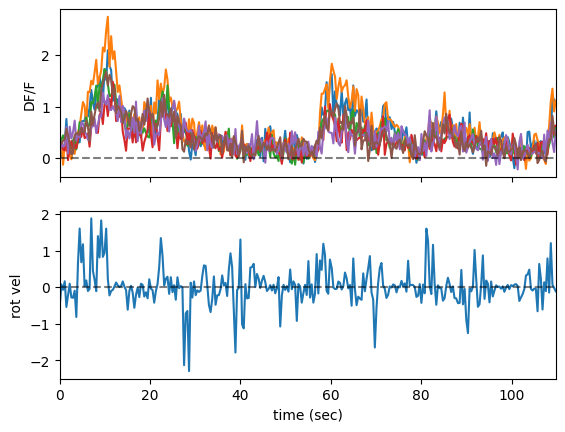

In [41]:
fig, axs = plt.subplots(2,1, sharex='col')

for i in range(6):
    axs[0].plot(expDf['posTime'], expDf[f'roi{i}'])
axs[1].plot(expDf['posTime'], expDf['vRfilt'])

for i in range(2):
    axs[i].axhline(y=0, color='black', linestyle='--', zorder=2, alpha=0.5)

axs[0].set_xlim([round(expDf.iloc[0]['posTime']), expDf.iloc[-1]['posTime']])

axs[0].set_ylabel("DF/F")
axs[1].set_ylabel("rot vel")
axs[1].set_xlabel("time (sec)")
